# Introduction to Machine Learning

Runnable examples for every discussion point in *Machine Learning Part 1 - Introduction to Machine Learning*.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (7, 4.5)
print("Environment ready.")

Environment ready.


## 1. What is Machine Learning?

> Machine learning is the field of study that gives computers the ability to improve at a task through experience — instead of being explicitly programmed with the rules for that task.

**Traditional programming**: a human works out the logic and writes it down. The computer only executes it.
**Machine learning**: the computer infers the logic from examples. We supply data, not instructions.

Below, both approaches solve the *same* task — deciding whether a student passes — so you can see the difference directly.

**What the code below does:** `traditional_pass_fail()` is a plain Python function with an `if` statement — a human (us) decided the exact threshold (`hours_studied >= 5 and attendance_pct >= 75`) that separates pass from fail. We then apply that fixed rule to a small table of students. This is "traditional programming": the logic lives in the code we wrote, not in the data.

In [2]:
# --- Traditional programming: a human writes the rule ---

def traditional_pass_fail(hours_studied: float, attendance_pct: float) -> str:
    """Hand-written rule: pass if enough study time AND attendance."""
    if hours_studied >= 5 and attendance_pct >= 75:
        return "pass"
    return "fail"

students = pd.DataFrame({
    "hours_studied": [1, 3, 5, 6, 8, 2, 7, 4],
    "attendance_pct": [40, 60, 80, 90, 95, 50, 40, 85],
})
students["traditional_prediction"] = students.apply(
    lambda row: traditional_pass_fail(row.hours_studied, row.attendance_pct), axis=1
)
students

,hours_studied,attendance_pct,traditional_prediction
0,1,40,fail
1,3,60,fail
2,5,80,pass
3,6,90,pass
4,8,95,pass
5,2,50,fail
6,7,40,fail
7,4,85,fail


**What the code below does:** Now we solve the *same* problem the ML way. We generate 200 synthetic students (`hours`, `attendance`) and a `passed` label for each — this label stands in for real historical outcomes. We hand `X_train` (the inputs) and `y_train` (the correct answers) to `DecisionTreeClassifier.fit()`. Nobody wrote an `if` statement — the tree figures out its own thresholds by looking for the splits that best separate pass from fail in the data. We then use that learned model to predict on the same students table as before, so you can compare its answers to the hand-written rule's answers directly.

In [3]:
# --- Machine learning: the computer infers the rule from labelled examples ---
from sklearn.tree import DecisionTreeClassifier, plot_tree

# We supply data (X = features, y = correct answers) — no rules.
rng = np.random.default_rng(RANDOM_STATE)
n = 200
hours = rng.uniform(0, 10, n)
attendance = rng.uniform(30, 100, n)
# "True" underlying pattern (unknown to the model) + noise, used only to label training data
passed = ((hours * 6 + attendance) > 130).astype(int)

X_train = pd.DataFrame({"hours_studied": hours, "attendance_pct": attendance})
y_train = passed

model = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
model.fit(X_train, y_train)  # the model learns the logic itself

students["ml_prediction"] = model.predict(
    students[["hours_studied", "attendance_pct"]]
)
students["ml_prediction"] = students["ml_prediction"].map({1: "pass", 0: "fail"})
students

,hours_studied,attendance_pct,traditional_prediction,ml_prediction
0,1,40,fail,fail
1,3,60,fail,fail
2,5,80,pass,fail
3,6,90,pass,fail
4,8,95,pass,pass
5,2,50,fail,fail
6,7,40,fail,fail
7,4,85,fail,fail


**What the code below does:** `plot_tree()` draws the actual decision logic the tree learned — each box is a question like "is `hours_studied <= 4.9`?", and following the branches down shows exactly how it reaches pass/fail. This is the ML equivalent of the `if` statement above, except the thresholds and which features to check were *discovered from data*, not written by hand.

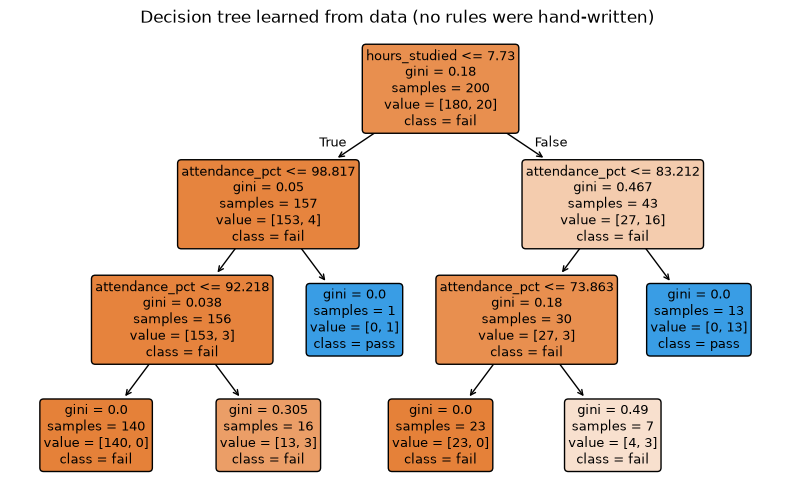

In [4]:
# Visualise the rule the model discovered on its own (no human wrote this logic)
fig, ax = plt.subplots(figsize=(10, 6))
plot_tree(
    model,
    feature_names=["hours_studied", "attendance_pct"],
    class_names=["fail", "pass"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision tree learned from data (no rules were hand-written)")
plt.show()

## 2. AI vs. Machine Learning vs. Deep Learning

| | Artificial Intelligence | Machine Learning | Deep Learning |
|---|---|---|---|
| **Scope** | Any technique that mimics intelligent behaviour | Systems that learn patterns from data | Learning with deep neural networks |
| **Data needed** | May need none (rule-based) | Hundreds to hundreds of thousands of rows | Typically very large datasets |
| **Hardware** | Ordinary CPU | CPU is usually sufficient | GPU or TPU strongly preferred |
| **Example** | Expert system, A* pathfinding | Spam filter, credit scoring | Face recognition, machine translation |

Machine Learning is a *subset* of AI, and Deep Learning is a *subset* of Machine Learning. The cell below shows all three solving variants of the same "is it a cat photo?" style decision, using toy stand-ins so nothing needs downloading.

**What the code below does:** Three functions, each standing in for one row of the table above.

- `ai_rule_based()` — plain `if` logic, exactly like Section 1's traditional example. No data, no training, no `.fit()`.
- The **ML** block builds a small tabular dataset (`whisker_score`, `ear_pointiness`) — a couple hundred rows, matching "hundreds to thousands of rows" from the table — and fits a `LogisticRegression`. This is a lightweight model well suited to modest, structured data.
- The **Deep Learning** block uses `X_dl`, a 64-column array standing in for 64 flattened pixel values (a stand-in for an image). `MLPClassifier` is a small neural network with two hidden layers (`hidden_layer_sizes=(32, 16)`) — the same family of model as a CNN, just far smaller, so it trains instantly on your laptop instead of needing a GPU.

Each block prints an accuracy score so you can see all three actually run and produce an answer, just via very different mechanisms.

In [5]:
# AI (rule-based, no data needed): a hand-written expert-system rule
def ai_rule_based(is_bright: bool, has_whiskers: bool) -> str:
    """Classic AI: fixed if/else logic, no learning involved."""
    if has_whiskers and is_bright:
        return "likely a cat"
    return "unclear"

print("AI (rule-based):", ai_rule_based(is_bright=True, has_whiskers=True))

# ML (learns patterns from a modest, structured dataset)
from sklearn.linear_model import LogisticRegression

# Tabular features standing in for "hundreds to thousands of rows"
X_ml = pd.DataFrame({
    "whisker_score": rng.uniform(0, 1, 300),
    "ear_pointiness": rng.uniform(0, 1, 300),
})
y_ml = ((X_ml.whisker_score + X_ml.ear_pointiness) > 1.0).astype(int)

ml_model = LogisticRegression().fit(X_ml, y_ml)
print("ML (learned from tabular data): accuracy =", round(ml_model.score(X_ml, y_ml), 3))

# Deep Learning (a small neural net, standing in for a CNN over raw pixels)
from sklearn.neural_network import MLPClassifier

# Pretend each "image" is already flattened into pixel-like features (large input space)
X_dl = rng.uniform(0, 1, (300, 64))  # 64 "pixels" per sample
y_dl = (X_dl.mean(axis=1) > 0.5).astype(int)

dl_model = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=RANDOM_STATE)
dl_model.fit(X_dl, y_dl)
print("Deep Learning (small neural net over pixel-like features): accuracy =", round(dl_model.score(X_dl, y_dl), 3))

AI (rule-based): likely a cat
ML (learned from tabular data): accuracy = 0.977
Deep Learning (small neural net over pixel-like features): accuracy = 1.0


## 3. Three Types of Machine Learning

- **Supervised** — labelled data: every example carries its correct answer.
- **Unsupervised** — unlabelled data: inputs only, no correct answers given.
- **Reinforcement** — no dataset: an environment that returns rewards.

### 3a. Supervised Learning

The model is shown input–output pairs and learns the mapping **f(X) → y**, then applies it to data it has never seen.

- `f` — the function: the rule/model that does the work.
- `X` — the inputs (e.g. `hours_studied`, `attendance_pct`, `prev_grade`).
- `y` — the output: the prediction (e.g. passed or failed).
- `→` reads as "gives," "maps to," or "produces."

Supervised learning splits into two families:

| | Classification | Regression |
|---|---|---|
| **Label is** | A category | A continuous number |
| **Examples** | Spam or not spam? Pass or fail? Positive or negative review? What genre? | House price? Tomorrow's temperature? Customers today? Days until failure? |
| **Evaluated with** | Accuracy · Precision · Recall · F1 | MAE · RMSE · R² |

- **Accuracy** — how often am I right overall?
- **Precision** — when I say yes, how often am I right?
- **Recall** — of all the real cases, how many did I catch?
- **F1** — the balance of precision and recall.
- **MAE** — Mean Absolute Error. **RMSE** — Root Mean Squared Error. **R²** — coefficient of determination.

**What the code below does, step by step:**

1. Build 400 synthetic students with three features (`hours_studied`, `attendance_pct`, `prev_grade`) and compute a noisy `score`; students above the median score are labelled `pass` (`y=1`), the rest `fail` (`y=0`). This `y` is exactly the "correct answer" that makes this *supervised* learning.
2. `train_test_split()` sets aside 25% of the rows as a **test set** the model never trains on — this mirrors the workflow's "never touch the test set until evaluation" rule.
3. `LogisticRegression().fit(X_train, y_train)` learns the mapping f(X) → y from the training rows only.
4. `clf.predict(X_test)` produces predictions on the unseen test rows.
5. The four metrics from the table above are computed on those predictions: **accuracy** (overall correctness), **precision** (of predicted passes, how many really passed), **recall** (of actual passes, how many were caught), **F1** (their harmonic balance).
6. The confusion matrix at the end shows the raw counts behind those metrics — how many actual fails/passes were predicted as fail/pass.

In [6]:
### Classification example: "Will this student pass or fail?" (f(X) -> y, y is a category)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

n = 400
hours_studied = rng.uniform(0, 10, n)
attendance_pct = rng.uniform(30, 100, n)
prev_grade = rng.uniform(40, 100, n)

# ground truth pattern + noise -> the "correct answers" (labels) supervised learning needs
score = hours_studied * 5 + attendance_pct * 0.6 + prev_grade * 0.4 + rng.normal(0, 15, n)
y = (score > np.median(score)).astype(int)  # 1 = pass, 0 = fail

X = pd.DataFrame({
    "hours_studied": hours_studied,
    "attendance_pct": attendance_pct,
    "prev_grade": prev_grade,
})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

clf = LogisticRegression().fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}  (how often am I right overall?)")
print(f"Precision: {precision_score(y_test, y_pred):.3f}  (when I say pass, how often am I right?)")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}  (of all real passes, how many did I catch?)")
print(f"F1:        {f1_score(y_test, y_pred):.3f}  (balance of precision & recall)")

pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["actual fail", "actual pass"],
    columns=["predicted fail", "predicted pass"],
)

Accuracy:  0.810  (how often am I right overall?)
Precision: 0.878  (when I say pass, how often am I right?)
Recall:    0.720  (of all real passes, how many did I catch?)
F1:        0.791  (balance of precision & recall)


,predicted fail,predicted pass
actual fail,45,5
actual pass,14,36


**What the code below does:** Same shape as the classification example, but now `y` (`price`) is a **continuous number** instead of a category — this is what makes it regression, not classification.

1. Generate 300 synthetic houses from `size_sqm`, `bedrooms`, `age_years`, with `price` built from a linear formula plus random noise (so it's learnable but not perfectly predictable — like real data).
2. Split into train/test, then fit a `LinearRegression` — it learns a coefficient for each feature (e.g. "$/sqm") rather than a category boundary.
3. Compute the three regression metrics from the table: **MAE** (average dollar error, easy to interpret), **RMSE** (also in dollars, but squares errors first so big misses are penalised harder), **R²** (0–1 score for how much of the price variation the model explains; 1.0 would be a perfect fit).
4. The scatter plot puts actual price on the x-axis and predicted price on the y-axis — points sitting on the red dashed line are predicted exactly right; the tighter the cloud hugs that line, the better the model.

MAE:  $11,759  (average absolute error)
RMSE: $14,243  (penalises large errors more)
R^2:  0.992  (share of price variance explained by the model)


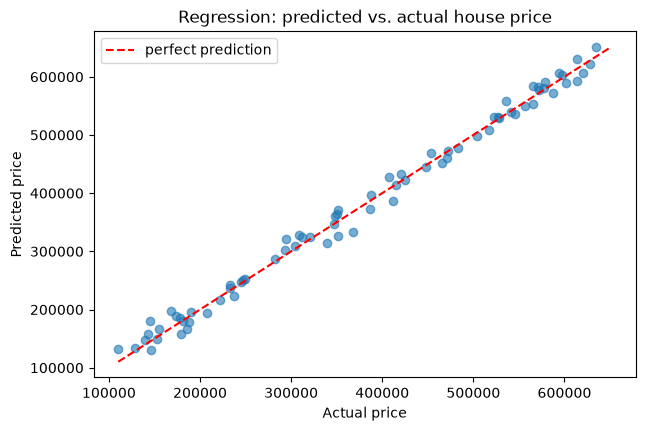

In [7]:
### Regression example: "What will this house sell for?" (y is a continuous number)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

n = 300
size_sqm = rng.uniform(40, 250, n)
bedrooms = rng.integers(1, 6, n)
age_years = rng.uniform(0, 50, n)

price = (
    size_sqm * 2500
    + bedrooms * 8000
    - age_years * 500
    + rng.normal(0, 15000, n)
    + 20000
)

X_house = pd.DataFrame({"size_sqm": size_sqm, "bedrooms": bedrooms, "age_years": age_years})
y_house = price

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_house, y_house, test_size=0.25, random_state=RANDOM_STATE
)

reg = LinearRegression().fit(Xh_train, yh_train)
yh_pred = reg.predict(Xh_test)

mae = mean_absolute_error(yh_test, yh_pred)
rmse = mean_squared_error(yh_test, yh_pred) ** 0.5
r2 = r2_score(yh_test, yh_pred)

print(f"MAE:  ${mae:,.0f}  (average absolute error)")
print(f"RMSE: ${rmse:,.0f}  (penalises large errors more)")
print(f"R^2:  {r2:.3f}  (share of price variance explained by the model)")

fig, ax = plt.subplots()
ax.scatter(yh_test, yh_pred, alpha=0.6)
lims = [min(yh_test.min(), yh_pred.min()), max(yh_test.max(), yh_pred.max())]
ax.plot(lims, lims, "r--", label="perfect prediction")
ax.set_xlabel("Actual price")
ax.set_ylabel("Predicted price")
ax.set_title("Regression: predicted vs. actual house price")
ax.legend()
plt.show()

### 3b. Unsupervised Learning

No answer key. The algorithm is asked to find structure that was already there but unlabelled.

**Clustering** — points grouped by similarity. Below, `KMeans` is given only raw points (no labels) and has to discover the groups on its own.

**What the code below does:** `make_blobs()` generates 300 points arranged into 4 natural groups — but critically, we only keep `X_customers` (the coordinates) and deliberately ignore `true_groups`, the ground-truth labels it also returns. That's the "unlabelled data" from the slide: the algorithm below never sees which group a point actually belongs to.

`KMeans(n_clusters=4).fit_predict(X_customers)` is told *how many* groups to look for, but not *where* they are or which point belongs to which — it has to find that structure purely from how close points are to each other. The left plot shows what the algorithm actually receives (plain gray dots); the right plot shows what it produced on its own (colored groups plus the cluster centers it converged on). Compare the two — the "before" (unlabelled) and "after" (discovered structure) is the core idea of unsupervised learning.

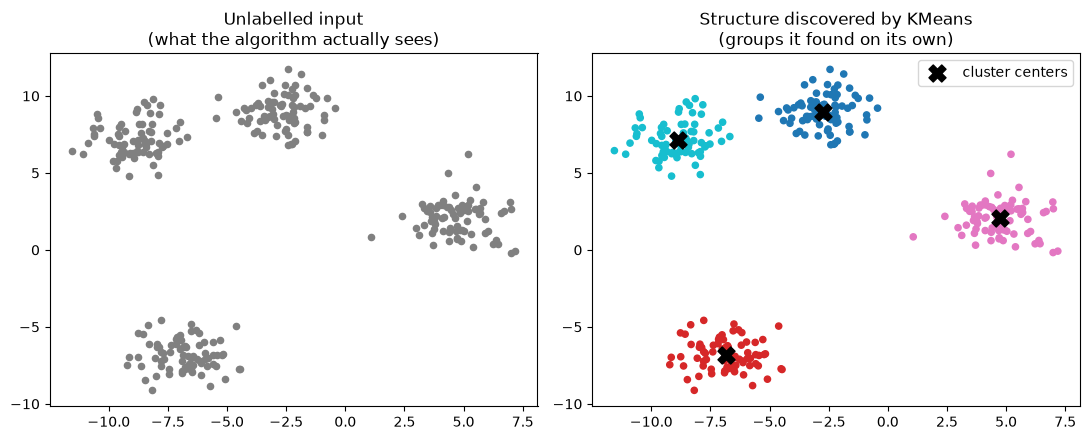

In [8]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Unlabelled data: only X (customer features), no y at all
X_customers, true_groups = make_blobs(
    n_samples=300, centers=4, cluster_std=1.1, random_state=RANDOM_STATE
)

kmeans = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE)
discovered_clusters = kmeans.fit_predict(X_customers)  # no labels were given, only X

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(X_customers[:, 0], X_customers[:, 1], c="gray", s=20)
axes[0].set_title("Unlabelled input\n(what the algorithm actually sees)")

axes[1].scatter(X_customers[:, 0], X_customers[:, 1], c=discovered_clusters, cmap="tab10", s=20)
axes[1].scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    c="black", marker="X", s=150, label="cluster centers",
)
axes[1].set_title("Structure discovered by KMeans\n(groups it found on its own)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3c. Reinforcement Learning

An agent learns by acting. There is no dataset of correct answers — only consequences, delivered as rewards and penalties.

Below is a minimal **multi-armed bandit**: an agent repeatedly picks one of several slot machines, each with a hidden (unknown) payout rate. There are no labelled examples — the agent only ever receives a reward after acting, and gradually learns which machine pays best purely through trial and error.

**What the code below does:** `true_payout_rates` are the real odds of each machine paying out — the agent is never shown this array; it exists only so we can simulate rewards.

Each round, the agent makes a choice:
- With probability `epsilon` (10%), it **explores**: tries a random machine, to keep learning about options it hasn't tried much.
- Otherwise it **exploits**: picks whichever machine currently has the highest `estimated_values` (its best guess so far).

After choosing, it receives a `reward` (1 or 0) drawn using the machine's *true* payout rate — this is the only information it ever gets, there is no `X`/`y` dataset anywhere in this cell. It then nudges `estimated_values[choice]` slightly toward that reward (a running average). Repeated 2000 times, the agent's estimates converge toward the true rates purely from this feedback loop. The plot shows average reward climbing toward the green dashed line (the best machine's true rate) as the agent learns which machine to favor.

True payout rates:      [0.2  0.35 0.55 0.3 ]
Agent's learned values: [0.206 0.328 0.551 0.291]
Times each machine was chosen: [  63   61 1821   55]


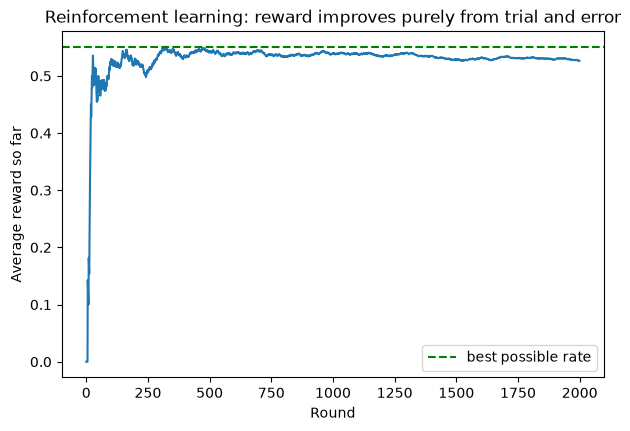

In [9]:
# True payout rates are hidden from the agent -- it must discover them via rewards only
true_payout_rates = np.array([0.20, 0.35, 0.55, 0.30])  # machine A, B, C, D
n_machines = len(true_payout_rates)
n_rounds = 2000
epsilon = 0.1  # exploration rate: chance of trying a random machine instead of the current best

estimated_values = np.zeros(n_machines)
pull_counts = np.zeros(n_machines)
reward_history = []
choice_history = []

for round_i in range(n_rounds):
    if rng.random() < epsilon:
        choice = rng.integers(n_machines)  # explore
    else:
        choice = np.argmax(estimated_values)  # exploit best-known machine

    reward = 1 if rng.random() < true_payout_rates[choice] else 0  # the *only* feedback signal

    pull_counts[choice] += 1
    estimated_values[choice] += (reward - estimated_values[choice]) / pull_counts[choice]

    reward_history.append(reward)
    choice_history.append(choice)

print("True payout rates:     ", true_payout_rates)
print("Agent's learned values:", estimated_values.round(3))
print("Times each machine was chosen:", pull_counts.astype(int))

fig, ax = plt.subplots()
running_avg_reward = np.cumsum(reward_history) / (np.arange(n_rounds) + 1)
ax.plot(running_avg_reward)
ax.axhline(true_payout_rates.max(), color="green", linestyle="--", label="best possible rate")
ax.set_xlabel("Round")
ax.set_ylabel("Average reward so far")
ax.set_title("Reinforcement learning: reward improves purely from trial and error")
ax.legend()
plt.show()

## 4. Which Paradigm Does My Problem Need?

Fraud detection is a good case study because all three paradigms can genuinely apply, depending on what data is available:

- **Supervised** — if past transactions are labelled fraud / not-fraud, train a classifier.
- **Unsupervised** — if there are no fraud labels yet, cluster/flag transactions that look anomalous compared to normal behaviour.
- **Reinforcement** — if the system takes actions (e.g. block, allow, escalate) and only later learns whether that action was costly, it can be framed as a reward-driven agent.

The cell below shows the supervised and unsupervised angles on the same synthetic transaction data.

**What the code below does:** We build 500 synthetic transactions, then deliberately corrupt 15 of them (`fraud_idx`) to look unusual — larger `amount` and higher `deviation_from_usual`. `is_fraud` records the ground truth, but the two models are given very different amounts of access to it:

- **Supervised angle** — `fraud_clf` is trained with `is_fraud` as `y`, exactly like the classification example earlier. It needs those historical fraud labels to exist.
- **Unsupervised angle** — `IsolationForest` never sees `is_fraud` at all (`fit_predict(X_tx)` — no `y` argument). It works by isolating points that are "easy to separate" from the rest of the data, which tends to catch outliers. `contamination=0.03` just tells it roughly what fraction of points to expect as anomalies.

The printed numbers let you compare: the supervised model's precision/recall (needs labels), versus how many of the unsupervised model's flagged anomalies were *actually* fraud (needs no labels). The scatter plot overlays both: gray points are normal, orange rings are what the unsupervised model flagged, and red-outlined points are the actual injected fraud — good overlap between orange and red means the anomaly detector is doing useful work without ever having been told what fraud looks like.

Supervised fraud detector (labels available):
  Precision: 1.000  Recall: 1.000

Unsupervised anomaly detector (no labels used): flagged 15 of 500 transactions
  Of those flagged, 14 were actually fraud


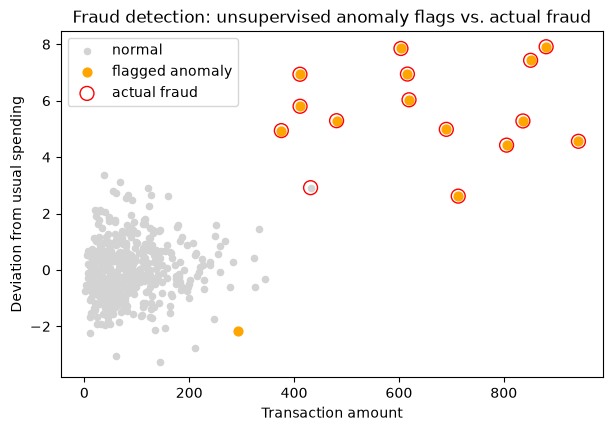

In [10]:
from sklearn.ensemble import IsolationForest

# Simulated transactions: amount and how far from the customer's usual spending pattern
n_tx = 500
amount = rng.gamma(shape=2.0, scale=40, size=n_tx)
deviation_from_usual = rng.normal(0, 1, n_tx)

# Inject a small number of fraudulent-looking transactions
fraud_idx = rng.choice(n_tx, size=15, replace=False)
amount[fraud_idx] += rng.uniform(300, 800, size=15)
deviation_from_usual[fraud_idx] += rng.uniform(4, 8, size=15)

is_fraud = np.zeros(n_tx, dtype=int)
is_fraud[fraud_idx] = 1

X_tx = pd.DataFrame({"amount": amount, "deviation_from_usual": deviation_from_usual})

# --- Supervised angle: we DO have fraud labels from past investigations ---
Xtx_train, Xtx_test, ytx_train, ytx_test = train_test_split(
    X_tx, is_fraud, test_size=0.3, random_state=RANDOM_STATE, stratify=is_fraud
)
fraud_clf = LogisticRegression(class_weight="balanced").fit(Xtx_train, ytx_train)
ytx_pred = fraud_clf.predict(Xtx_test)
print("Supervised fraud detector (labels available):")
print(f"  Precision: {precision_score(ytx_test, ytx_pred):.3f}  Recall: {recall_score(ytx_test, ytx_pred):.3f}")

# --- Unsupervised angle: pretend we have NO fraud labels, only flag anomalies ---
anomaly_detector = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)
anomaly_flag = anomaly_detector.fit_predict(X_tx)  # -1 = anomaly, 1 = normal; no y used at all
flagged = (anomaly_flag == -1)
print(f"\nUnsupervised anomaly detector (no labels used): flagged {flagged.sum()} of {n_tx} transactions")
print(f"  Of those flagged, {is_fraud[flagged].sum()} were actually fraud")

fig, ax = plt.subplots()
ax.scatter(X_tx.amount, X_tx.deviation_from_usual, c="lightgray", s=20, label="normal")
ax.scatter(X_tx.amount[flagged], X_tx.deviation_from_usual[flagged], c="orange", s=40, label="flagged anomaly")
ax.scatter(X_tx.amount[fraud_idx], X_tx.deviation_from_usual[fraud_idx], facecolors="none", edgecolors="red", s=100, label="actual fraud")
ax.set_xlabel("Transaction amount")
ax.set_ylabel("Deviation from usual spending")
ax.set_title("Fraud detection: unsupervised anomaly flags vs. actual fraud")
ax.legend()
plt.show()

## 5. The Machine Learning Workflow

1. **Problem framing** — define the target, the success metric, and what a useful answer looks like.
2. **Data collection** — gather sources, read them into pandas, merge into one working table.
3. **EDA / cleaning** — missing values, duplicates, outliers, type fixes. The longest step.
4. **Feature engineering** — encode categories, scale numbers, create informative derived columns.
5. **Modelling** — split the data, choose an algorithm, call `fit()` on the training set only.
6. **Evaluation** — score on held-out data, cross-validate, tune hyperparameters.
7. **Deployment & monitoring** — ship it, then watch for drift as the world changes underneath it.

> The loop: poor evaluation scores send you back to feature engineering, or all the way back to problem framing. Expect to go around several times — and never touch the test set until the very end.

Below, we walk through all seven steps on one small, deliberately messy dataset.

**What the code below does:** No modelling yet — this step is just writing down, in plain language, what "success" means before touching any data. Skipping this step is a common real-world mistake: teams build a model, then discover nobody agreed on what metric mattered or what a "useful" prediction even looks like.

In [11]:
### Step 1: Problem framing
# Target: predict whether a customer will churn (leave).
# Success metric: F1 (churn is imbalanced -- accuracy alone would be misleading).
# A useful answer: a probability we can rank customers by for a retention campaign.
print("Target: churn (0/1). Metric: F1. Output: churn probability per customer.")

Target: churn (0/1). Metric: F1. Output: churn probability per customer.


**What the code below does:** We simulate pulling data from two different systems — `accounts` (billing info) and `support` (ticket counts) — the way you might read one table from a CRM and another from a support-desk export. `.merge(..., on="customer_id", how="left")` joins them into a single working table, `raw`, exactly as the slide describes ("gather sources... merge into one working table"). We then deliberately inject 20 missing `monthly_charge` values and one duplicated row, so Step 3 has real messiness to clean up — real-world data almost never arrives this tidy.

In [12]:
### Step 2: Data collection -- gather sources and merge into one working table
n_customers = 600

accounts = pd.DataFrame({
    "customer_id": range(n_customers),
    "tenure_months": rng.integers(1, 60, n_customers),
    "monthly_charge": rng.uniform(20, 120, n_customers).round(2),
    "contract_type": rng.choice(["month-to-month", "one-year", "two-year"], n_customers, p=[0.55, 0.25, 0.20]),
})

support = pd.DataFrame({
    "customer_id": range(n_customers),
    "support_tickets": rng.poisson(1.5, n_customers),
})

# Merge two separate sources into one working table, like pulling from two systems
raw = accounts.merge(support, on="customer_id", how="left")

# Introduce realistic messiness: missing values and a duplicate row
raw.loc[rng.choice(n_customers, 20, replace=False), "monthly_charge"] = np.nan
raw = pd.concat([raw, raw.iloc[[0]]], ignore_index=True)  # accidental duplicate

print("Working table shape:", raw.shape)
raw.head()

Working table shape: (601, 5)


,customer_id,tenure_months,monthly_charge,contract_type,support_tickets
0,0,27,116.54,one-year,2
1,1,53,57.51,one-year,1
2,2,53,28.80,two-year,0
3,3,36,24.77,month-to-month,0
4,4,53,103.34,two-year,0


**What the code below does:** `.isna().sum()` counts missing values per column, and `.duplicated().sum()` counts exact duplicate rows — this is the diagnostic part of EDA, finding out what's wrong before fixing anything. `drop_duplicates()` removes the repeated row; `.fillna(median)` fills the missing charges with the column's median (a common, robust default — it isn't skewed by outliers the way a mean would be). The histogram is exploratory visualization: a quick look at how `tenure_months` is distributed across customers, checking for anything unexpected (like an odd spike or an impossible value) before moving on.

Missing values per column:
customer_id         0
tenure_months       0
monthly_charge     20
contract_type       0
support_tickets     0
dtype: int64

Duplicate rows: 1


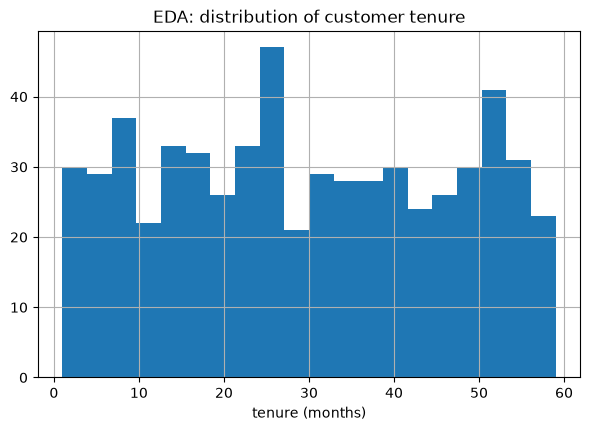


After cleaning: (600, 5) -- no missing values: True


In [13]:
### Step 3: EDA and cleaning -- missing values, duplicates, outliers, type fixes
print("Missing values per column:")
print(raw.isna().sum())
print("\nDuplicate rows:", raw.duplicated().sum())

df = raw.drop_duplicates().copy()
df["monthly_charge"] = df["monthly_charge"].fillna(df["monthly_charge"].median())

fig, ax = plt.subplots()
df["tenure_months"].hist(bins=20, ax=ax)
ax.set_title("EDA: distribution of customer tenure")
ax.set_xlabel("tenure (months)")
plt.show()

print("\nAfter cleaning:", df.shape, "-- no missing values:", df.isna().sum().sum() == 0)

**What the code below does:**

- `pd.get_dummies(..., columns=["contract_type"])` **encodes the category** column into numeric 0/1 columns (e.g. `contract_type_one-year`) — models need numbers, not text labels.
- `charge_per_tenure_month` is a **derived feature**: a new, informative column computed from two existing ones (spend relative to how long they've been a customer), which can carry signal neither original column captures alone.
- `churn_score` and the resulting `churn` column simulate the "correct answer" we'd normally get from historical business outcomes — here we invent it from a weighted combination of the features plus noise, purely so there's something realistic to predict in Step 5.
- `StandardScaler().fit_transform()` **scales the numbers** so every feature has mean 0 and standard deviation 1 — this stops features with naturally larger ranges (like `monthly_charge` in dollars) from dominating features with smaller ranges (like `support_tickets`, typically 0–5) just because of their units.

In [14]:
### Step 4: Feature engineering -- encode categories, scale numbers, derive new columns
from sklearn.preprocessing import StandardScaler

df = pd.get_dummies(df, columns=["contract_type"], drop_first=True)  # encode categories

# Derived, informative column: spend per month of tenure so far
df["charge_per_tenure_month"] = df["monthly_charge"] / df["tenure_months"].clip(lower=1)

# Synthetic churn label correlated with the features (stands in for real historical outcomes)
churn_score = (
    -0.05 * df["tenure_months"]
    + 0.03 * df["monthly_charge"]
    + 0.8 * df["support_tickets"]
    - 3 * df.get("contract_type_two-year", 0)
    + rng.normal(0, 2, len(df))
)
df["churn"] = (churn_score > np.percentile(churn_score, 75)).astype(int)  # ~25% churn rate

feature_cols = [c for c in df.columns if c not in ("customer_id", "churn")]
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])  # scale numbers

print("Churn rate:", df["churn"].mean().round(3))
df[feature_cols + ["churn"]].head()

Churn rate: 0.25


,tenure_months,monthly_charge,support_tickets,contract_type_one-year,contract_type_two-year,charge_per_tenure_month,churn
0,-0.157997,1.578087,0.373759,1.651275,-0.502603,-0.104845,1
1,1.384403,-0.451205,-0.418663,1.651275,-0.502603,-0.402249,0
2,1.384403,-1.438178,-1.211084,-0.605593,1.989643,-0.452107,0
3,0.375911,-1.576718,-1.211084,-0.605593,-0.502603,-0.438793,0
4,1.384403,1.124307,-1.211084,-0.605593,1.989643,-0.322659,0


**What the code below does:** `train_test_split(..., stratify=y_churn)` splits the cleaned, engineered data into training and test sets — `stratify` keeps the ~25% churn rate consistent in both splits, which matters for an imbalanced target like churn. We then pick an algorithm, `RandomForestClassifier` (an ensemble of many decision trees, generally a strong default for tabular data), and call `.fit()` **on the training set only**. The test set (`Xc_test`, `yc_test`) is created here but deliberately left untouched — it's saved for Step 6, matching the workflow's rule of never peeking at test data during training.

In [15]:
### Step 5: Modelling -- split the data, choose an algorithm, fit() on the training set only
from sklearn.ensemble import RandomForestClassifier

X_churn = df[feature_cols]
y_churn = df["churn"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=RANDOM_STATE, stratify=y_churn
)

churn_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
churn_model.fit(Xc_train, yc_train)  # test set is untouched until Step 6

print(f"Trained on {len(Xc_train)} rows, held out {len(Xc_test)} rows for evaluation.")

Trained on 480 rows, held out 120 rows for evaluation.


**What the code below does:**

1. `f1_score(yc_test, yc_pred)` — finally uses the held-out test set from Step 5 to get an honest score on data the model has never seen.
2. `cross_val_score(..., cv=5)` — **cross-validation**: instead of one train/test split, it splits the full data 5 different ways, trains and scores 5 times, and reports all 5 F1 scores plus their mean. This gives a more reliable estimate than a single split, and shows how much the score varies depending on which rows land in training vs. test.
3. `GridSearchCV(...)` — **hyperparameter tuning**: it systematically tries every combination in `param_grid` (3 values of `max_depth` × 3 values of `min_samples_leaf` = 9 combinations), cross-validating each one, and reports which combination scored best. This automates the "tune hyperparameters" step from the workflow instead of guessing values by hand.

In [16]:
### Step 6: Evaluation -- score on held-out data, cross-validate, tune hyperparameters
from sklearn.model_selection import cross_val_score, GridSearchCV

yc_pred = churn_model.predict(Xc_test)
print("Held-out test F1:", round(f1_score(yc_test, yc_pred), 3))

cv_scores = cross_val_score(churn_model, X_churn, y_churn, cv=5, scoring="f1")
print("5-fold cross-validated F1:", cv_scores.round(3), "-> mean", round(cv_scores.mean(), 3))

# Hyperparameter tuning
param_grid = {"max_depth": [3, 5, None], "min_samples_leaf": [1, 5, 10]}
grid = GridSearchCV(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    param_grid, scoring="f1", cv=3,
)
grid.fit(Xc_train, yc_train)
print("\nBest hyperparameters found:", grid.best_params_)
print("Best cross-val F1 during tuning:", round(grid.best_score_, 3))

Held-out test F1: 0.423


5-fold cross-validated F1: [0.5   0.473 0.467 0.5   0.423] -> mean 0.472



Best hyperparameters found: {'max_depth': None, 'min_samples_leaf': 5}
Best cross-val F1 during tuning: 0.49


**What the code below does:**

- `grid.best_estimator_` retrieves the winning model from Step 6's hyperparameter search.
- `pickle.dumps()` serializes it into bytes — a stand-in for "ship it": in a real system, these bytes would be saved to a file or model registry and loaded by a prediction service.
- `score_new_customers()` shows the shape a production function would take — scale new incoming data with the *same* fitted `scaler` (never re-fit it on new data), then return churn probabilities with `.predict_proba()`.
- The final plot simulates **monitoring for drift**: we compare the `tenure_months` distribution the model was trained on against a synthetic batch of "live traffic" that skews toward newer customers. In production you'd track this kind of shift over time — if live data drifts far enough from what the model learned on, its predictions become less trustworthy, which is exactly the workflow's "watch for drift... loop back" step.

Serialized model ready to deploy (1,167,489 bytes).


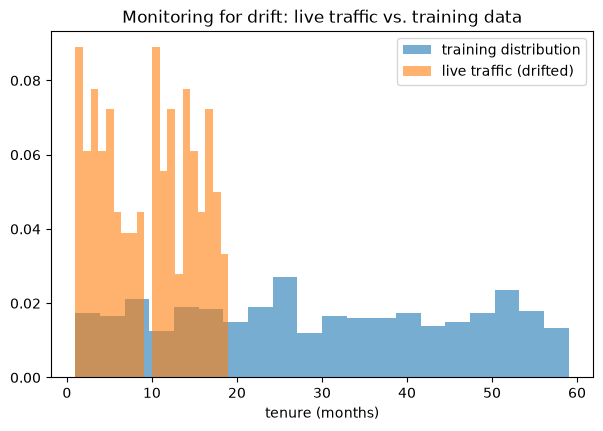


If live traffic keeps drifting away from the training distribution, loop back
to Step 4 (feature engineering) or Step 2 (fresh data collection) and retrain.


In [17]:
### Step 7: Deployment & monitoring -- ship it, then watch for drift
import pickle

final_model = grid.best_estimator_

# "Ship it": serialize the trained model so a service could load it later
model_bytes = pickle.dumps(final_model)
print(f"Serialized model ready to deploy ({len(model_bytes):,} bytes).")

def score_new_customers(model, scaler, feature_cols, new_df):
    """What a production service would call on fresh, incoming data."""
    X_new = new_df[feature_cols].copy()
    X_new[feature_cols] = scaler.transform(X_new[feature_cols])
    return model.predict_proba(X_new)[:, 1]

# Simulate monitoring: compare the feature distribution of new incoming traffic to training data
incoming_tenure = rng.integers(1, 20, 200)  # e.g. drifted -- skews newer than training data
fig, ax = plt.subplots()
ax.hist(accounts["tenure_months"], bins=20, alpha=0.6, label="training distribution", density=True)
ax.hist(incoming_tenure, bins=20, alpha=0.6, label="live traffic (drifted)", density=True)
ax.set_xlabel("tenure (months)")
ax.set_title("Monitoring for drift: live traffic vs. training data")
ax.legend()
plt.show()

print("\nIf live traffic keeps drifting away from the training distribution, loop back")
print("to Step 4 (feature engineering) or Step 2 (fresh data collection) and retrain.")

## Summary

| Slide topic | What we ran |
|---|---|
| Traditional programming vs. ML | Hand-written rule vs. a learned `DecisionTreeClassifier` |
| AI vs. ML vs. Deep Learning | Rule-based function, `LogisticRegression`, small `MLPClassifier` |
| Supervised — classification | Pass/fail prediction with accuracy, precision, recall, F1 |
| Supervised — regression | House price prediction with MAE, RMSE, R² |
| Unsupervised — clustering | `KMeans` discovering groups with no labels |
| Reinforcement learning | Multi-armed bandit learning purely from reward |
| Choosing a paradigm (fraud) | Supervised classifier vs. unsupervised `IsolationForest` |
| The ML workflow | All 7 steps, end-to-end, on a synthetic churn dataset |

All datasets here are synthetic and generated in-notebook so every cell runs offline, with no external downloads required.